<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/MLP/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP

## Import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [ ]:
# Load dataset
file_path = "/content/synthetic_data_cleaned_feature_engineered.csv"
df = pd.read_csv(file_path, sep="|")
#df = pd.read_csv(file_path)
# View first rows
df.head()


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Loan_Officer_Note,Default_Status,Occupation,Has_Asset,Risk_Flag,DTI_Ratio,Log_Income
0,CUST-4321,55,120000,770,160000,48,Teaching assistant facing sudden hospital bill...,1,Education,0,0,1.333322,11.695255
1,CUST-2056,40,150000,780,90000,36,Photographer inherits art collection easing fi...,0,Other,0,0,0.599996,11.918397
2,CUST-9812,34,75000,660,110000,48,Retail store owner deals daily challenges due ...,1,Service,0,0,1.466647,11.225257
3,CUST-8132,28,32000,710,60000,24,Software developer secures bonus which helps c...,0,Tech,1,0,1.874941,10.373522
4,CUST-0543,45,80000,820,240000,72,Business consultant recently benefited from su...,1,Business,0,0,2.999963,11.289794


In [ ]:
df.isnull().sum()


,0
Customer_ID,0
Age,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Loan_Officer_Note,0
Default_Status,0
Occupation,0
Has_Asset,0


## Data Preprocessing

### Train-Test Split (80% Train, 20% Test)

In [ ]:
X = df.drop(columns=["Default_Status"])
y = df["Default_Status"]
#X = df.drop(columns=["default_risk"])
#y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Identify categorical and numeric columns


In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))




Categorical columns: ['Customer_ID', 'Loan_Officer_Note', 'Occupation']
Numeric columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


### Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)


## Build MLP Pipeline

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
       # ("smote", SMOTE(random_state=45)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]
)


## Train Model

In [ ]:
mlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.7945
Precision: 0.7857
Recall   : 0.7097
F1-score : 0.7458
ROC-AUC:, 0.7834


### Evaluation Report

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       126
           1       0.79      0.71      0.75        93

    accuracy                           0.79       219
   macro avg       0.79      0.78      0.79       219
weighted avg       0.79      0.79      0.79       219



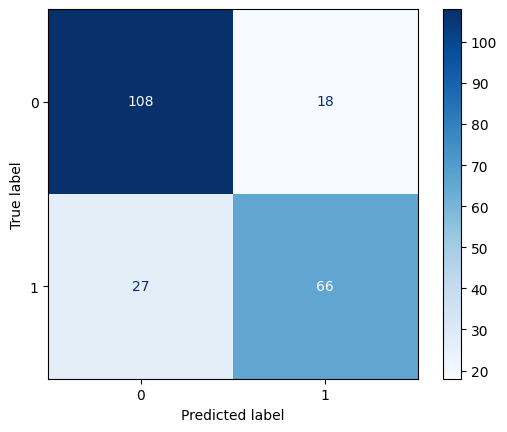

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


## Hypertune

### Optuna

In [ ]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.3 MB/s eta 0:00:00


In [ ]:
def objective(trial):

    hidden_layer_sizes = (
        trial.suggest_int("n_units_l1", 32, 128),
        trial.suggest_int("n_units_l2", 16, 64)
    )

    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=300,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", mlp)
        ]
    )

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)


[I 2026-01-18 17:20:29,238] A new study created in memory with name: no-name-fc2ae238-9745-45ff-a4a1-c7a688969c5c
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[I 2026-01-18 17:20:37,341] Trial 0 finished with value: 0.8628036880485901 and parameters: {'n_units_l1': 46, 'n_units_l2': 53, 'alpha': 0.005434797558241521, 'learning_rate_init': 0.0010005912161508087}. Best 

In [ ]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)


Best ROC-AUC: 0.8819179999957689
Best Parameters: {'n_units_l1': 104, 'n_units_l2': 30, 'alpha': 3.759187927626414e-05, 'learning_rate_init': 0.00010197334077425832}


#Hypertune Model

In [ ]:
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(104, 30),  # n_units_l1, n_units_l2
            activation="relu",
            solver="adam",
            alpha=3.759187927626414e-05,
            learning_rate_init=0.00010197334077425832,
            max_iter=300,
            random_state=42
        ))
    ]
)


## Run  Model with Hyperparameter

In [ ]:
mlp_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(alpha=3.759187927626414e-05,
                               hidden_layer_sizes=(104, 30),
                               learning_rate_init=0.00010197334077425832,
                               max_iter=300, random_state=42))])

## Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.8174
Precision: 0.8630
Recall   : 0.6774
F1-score : 0.7590
ROC-AUC:, 0.7990


### Evaluation Report

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       126
           1       0.86      0.68      0.76        93

    accuracy                           0.82       219
   macro avg       0.83      0.80      0.81       219
weighted avg       0.82      0.82      0.81       219



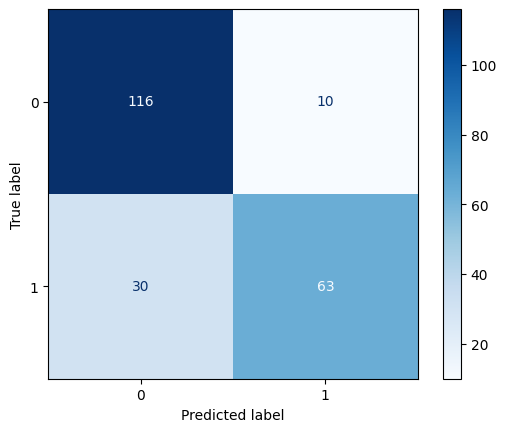

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": auc
}

In [ ]:
prompt = f"""
You are a senior data science consultant.
I trained a Multi-Layer Perceptron (MLP) on a financial dataset to predict loan defaults.
Here are the performance metrics:

- Accuracy: {metrics['accuracy']:.2%}
- Precision: {metrics['precision']:.2%}
- Recall: {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC: {metrics['roc_auc']:.2%}

Please provide:
1. Summary of model performance
2. Key strengths and weaknesses
3. Suggestions for improvement (hyperparameters, architecture, data)
4. Interpretation of feature importance for an MLP
5. Any potential risks or biases (financial context)
Format your response in a clear, structured, professional report style.
"""

In [ ]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)


In [ ]:
# ==============================
# 3. GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
# 4. OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

## MLP Model Performance Report: Loan Default Prediction

**Date:** October 26, 2023
**To:** Stakeholders
**From:** Senior Data Science Consultant
**Subject:** Analysis of Multi-Layer Perceptron (MLP) Model for Loan Default Prediction

---

### 1. Summary of Model Performance

The Multi-Layer Perceptron (MLP) model developed for predicting loan defaults demonstrates a reasonable level of performance, achieving an overall accuracy of 81.74%. The model shows a strong ability to correctly identify non-defaulting loans and, when it predicts a default, it is largely correct (high precision). However, there is a noticeable gap in its ability to identify all actual default cases, indicating room for improvement, particularly in mitigating potential financial losses from missed defaults. The ROC-AUC score suggests good discriminative power, indicating the model generally separates defaulters from non-defaulters well across various decision thresholds.

### 2. Key Strengths and Weaknesses

**St

In [ ]:
v

#